In [1]:
from bcitoolbox_local import simulateVV, fit
import pandas as pd
import numpy as np
# import cupy as cp
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import wilcoxon
import statsmodels.api as sm
from collections import defaultdict

In [2]:
strategy_map = {
    'Averaging': 'ave',
    'Selection': 'sel',
    'Matching': 'mat',
}

model_map = {
    'bci': 'Bayesian Causal Inference',
    'ff':  'Forced Fusion',
    'mle': 'Maximum Likelihood estimation',
    'fs': 'Full Segregation'
}


location_map = {
    'all': 'All',
    'blindspot': 'Blind Spot',
    'control': 'Control',
}

param_groups = {
    'Prior': ['pcommon', 'sigma_p', 'mu_p'],
    'Visual': ['sigma_v'],
    'Auditory': ['sigma_a'],
    'Model': ['r2', 'bic']
}

def simulate_data(parameters, strategy_name, fitType, file_name,
                  modeling_data_path='csv/modeling/',
                  n_simulation=1000, biOnly=0):
    
    data_file_path = modeling_data_path + file_name
    behavior_data = np.loadtxt(data_file_path, delimiter=',')
    strategy = strategy_map.get(strategy_name[0])

    error, modelprop, dataprop, responsesSim, r2 = simulateVV(parameters, n_simulation, behavior_data, biOnly, strategy, fitType)

    return error, modelprop, dataprop, responsesSim, r2

def get_subject_ids():
    # Get unique subject IDs
    subject_ids = set()
    for filename in os.listdir('csv/modeling/'):
        if 'df_all' and 'SV0' in filename:
            parts = filename.split('_')
            subject = parts[-1].replace('.csv', '')    
            subject_ids.add(subject)
            
    return sorted(list(subject_ids))


def get_best_models(model, remove_all_loc=True):
    
    df = pd.read_csv(f'csv/modeling/{model}_best_models.csv')
    if remove_all_loc:
        df = df[df['location'] != 'all']
        
    return df

def get_all_models(model, strategy=None, remove_all_loc=True):
    
    df = pd.read_csv(f'csv/modeling/{model}_fitting_results.csv')
    if strategy is not None:
        df = df[df['strategy']==strategy]
    if remove_all_loc:
        df = df[df['location'] != 'all']
        
    return df


In [3]:
# parameter recovery

output_dir = 'csv/modeling/'
output_path = os.path.join(output_dir, 'parameter_recovery_fitting_results.csv')

if not os.path.exists(output_path):
    # store true and recovered parameters from all participants
    true_params_all = defaultdict(dict)
    recovered_params_all = defaultdict(dict)

    best_models_df = get_best_models('bci')

    fitting_results = []
    for location in ['blindspot', 'control']:
        location_df = best_models_df[best_models_df['location'] == location]

        for index, row in location_df.iterrows():
            subject = row['subject_id']
            file_name = f"df_{location}_{subject}.csv"
            Strategies = strategy_map.get(row['strategy'])
            FitType = row['fit_type']

            behavior_data = np.loadtxt(f'csv/modeling/{file_name}', delimiter=',')
            responses = behavior_data[:, [2, 3]]
            stimuli = behavior_data[:, [0, 1]]
            N = np.max(stimuli) + 1
            n_rep = 1000

            conditions = np.unique(stimuli, axis=0)
            # Real Stimuli, Repeat n times
            real = np.tile(conditions, (n_rep, 1))
            # print(real)
            _, trialTypeSim = np.unique(real, axis=0, return_inverse=True)

            true_params = [
                row['pcommon'],
                row['sigma_v'],
                row['sigma_a'],
                row['sigma_p'],
                row['mu_p'],
            ]

            # store true parameters
            true_params_all[subject][location] = {
                'pcommon':  row['pcommon'],
                'sigma_v': row['sigma_v'],
                'sigma_a': row['sigma_a'],
                'sigma_p': row['sigma_p'],
                'mu_p': row['mu_p']
            }

            # Simulate data based on true parameters
            err, modelprop, dataprop, responsesSim, r2 = simulateVV(
                paras=true_params,
                n=n_rep, 
                data=behavior_data,
                biOnly=0,
                strategy=Strategies,
                fitType=FitType,
            )
            
            rng = np.random.default_rng(13)

            n_trials = real.shape[0]
            resp_disc = np.zeros((n_trials, 2), dtype=int)

            # sample per condition for speed
            for j in range(modelprop.shape[1]):
                idx = np.where(trialTypeSim == j)[0]
                if idx.size == 0:
                    continue

                for i in range(2):  # 0: visual, 1: auditory (in your convention)
                    p = modelprop[i, j, :].astype(float)
                    p = p / (p.sum() + 1e-12)  # safety
                    resp_disc[idx, i] = rng.choice(len(p), size=idx.size, replace=True, p=p)

            synth = np.zeros((real.shape[0], 4))
            synth[:, 0:2] = real
            synth[:, 2] = resp_disc[:, 0]  # visual response (discrete)
            synth[:, 3] = resp_disc[:, 1]  # auditory response (discrete)

            # fit synthetic data

            est, err, strategy_name, bic, r2 = fit(
                n_parameters=5, 
                n_Simulation=10000, 
                Behavior_Data=synth,
                bounds=[(0, 1),(0.1, 3),(0.1, 3),(0.1,3),(0, 3.5)],
                es_para=[1,1,1,1,1,0,0], 
                fixvalue=[0.5,0.4,0.2,2,2,0,0], 
                Strategies=[Strategies], 
                FitType=FitType
                )
            
            # store recovered parameters
            recovered_params_all[subject][location] = {
                'pcommon':  est[0],
                'sigma_v': est[1],
                'sigma_a': est[2],
                'sigma_p': est[3],
                'mu_p': est[4]
            }

            result_dict = {
                'subject_id': subject,
                'location': location,
                'pcommon': est[0],
                'sigma_v': est[1],
                'sigma_a': est[2],
                'sigma_p': est[3],
                'mu_p': est[4],
                'error': err,
                'bic': bic,
                'r2': r2,
                'strategy': strategy_name,
                'fit_type': FitType
            }
            
            # Append the dictionary to your list
            fitting_results.append(result_dict)

    results_df = pd.DataFrame(fitting_results)
    results_df.to_csv(output_path, index=False)
else:
    print(f'Skipping parameter recovery; found existing file: {output_path}')


Skipping parameter recovery; found existing file: csv/modeling/parameter_recovery_fitting_results.csv


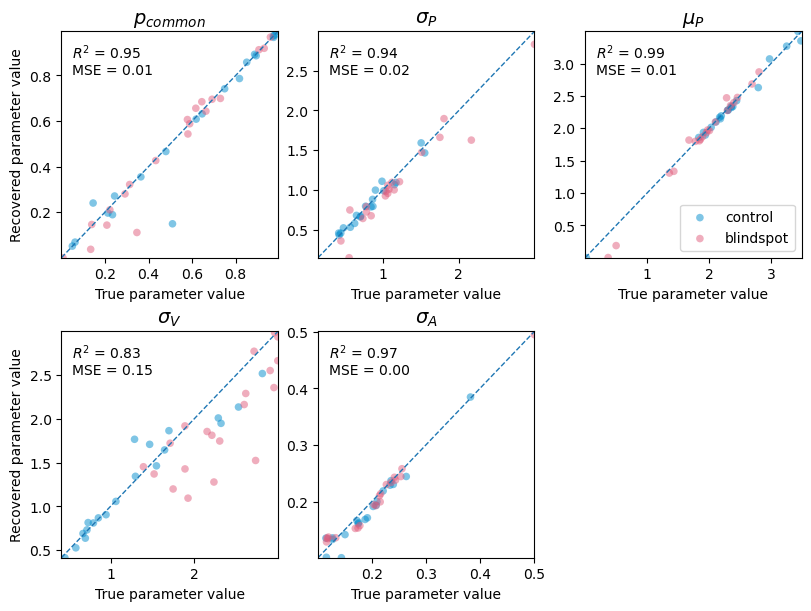

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

PARAMS = ["pcommon", "sigma_v", "sigma_a", "sigma_p", "mu_p"]
PLOT_ORDER = ["pcommon", "sigma_p", "mu_p", "sigma_v", "sigma_a"]

param_title = {
    "pcommon": r"$p_{common}$",
    "sigma_v": r"$\sigma_V$",
    "sigma_a": r"$\sigma_A$",
    "sigma_p": r"$\sigma_P$",
    "mu_p": r"$\mu_P$",
}

output_dir = 'csv/modeling/'
recoered_params_all = pd.read_csv(os.path.join(output_dir, 'parameter_recovery_fitting_results.csv'))

best_models_df = get_best_models('bci')[[
    'subject_id', 'location', 'pcommon', 'sigma_v', 'sigma_a', 'sigma_p', 'mu_p'
]].copy()

true_df = best_models_df.melt(
    id_vars=['subject_id', 'location'],
    value_vars=PARAMS,
    var_name='param',
    value_name='true'
)

recovered_df = recoered_params_all.melt(
    id_vars=['subject_id', 'location'],
    value_vars=PARAMS,
    var_name='param',
    value_name='recovered'
)

df = true_df.merge(recovered_df, on=['subject_id', 'location', 'param'])
df = df.rename(columns={'subject_id': 'subject'})

fig, axes = plt.subplots(
    2, 3,
    figsize=(8, 6),
    constrained_layout=True,
)
axes = axes.flatten()

colors = {
    "control": "#008ccd",
    "blindspot": "#e15c7c",
}

for ax, p in zip(axes, PLOT_ORDER):
    d = df[df["param"] == p]

    for loc, c in colors.items():
        dd = d[d["location"] == loc]
        ax.scatter(
            dd["true"].to_numpy(),
            dd["recovered"].to_numpy(),
            label=loc,
            alpha=0.5,
            color=c,
            s=30,
            edgecolors="none",
        )

    # limits based on both axes
    lo = float(min(d["true"].min(), d["recovered"].min()))
    hi = float(max(d["true"].max(), d["recovered"].max()))
    if np.isclose(lo, hi):
        pad = 1.0 if lo == 0 else abs(lo) * 0.1
        lo -= pad
        hi += pad

    # diagonal
    ax.plot([lo, hi], [lo, hi], linewidth=1, linestyle="--")

    x = d["true"].to_numpy()
    y = d["recovered"].to_numpy()

    r, _ = pearsonr(x, y)
    r2 = r ** 2
    mse = np.mean((x - y) ** 2)

    ax.text(
        0.05, 0.95,
        f"$R^2$ = {r2:.2f}\nMSE = {mse:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
    )

    ax.set_title(param_title[p], fontsize=14)
    ax.set_xlabel("True parameter value")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

axes[0].set_ylabel("Recovered parameter value")
axes[3].set_ylabel("Recovered parameter value")
axes[2].legend(frameon=True, loc="best")
axes[5].axis("off")

plt.savefig('../plots/parameter_recovery_blindspot.png', dpi=300)
plt.show()
